In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.plot_utils import *
from utils.problem import *
from utils.optimizer import *
from utils.homeomorphism import *
from utils.solver_utils import *

In [2]:
folder = 'pics/ConvexOpt/records/Hom-PGD/'
ori_file_name = f'0_ConvexOpt_obj_quad_WS_False_gd_False_100_1000_record.npy'
ori_results = np.load(folder+ori_file_name, allow_pickle=True).item()

smooth_file_name = f'0_ConvexOpt_obj_quad_WS_False_gd_True_100_1000_record.npy'
smooth_results = np.load(folder+smooth_file_name, allow_pickle=True).item()

In [7]:
folder = 'pics/ConvexOpt/records/Hom-PGD/'
ori_file_name = f'0_ConvexOpt_obj_quad_WS_False_gd_False_50_150_record.npy'
ori_results = np.load(folder+ori_file_name, allow_pickle=True).item()

iter_cost = np.sum(ori_results['iter_time'])
ip_cost = ori_results['ip_time']
post_cost = ori_results['last_trans_time']
total_cost = iter_cost + ip_cost + post_cost
print(f'ip_cost: {ip_cost/total_cost*100:.3}%, iter_cost: {iter_cost/total_cost*100:.3f}%, post_cost: {post_cost/total_cost*100:.4f}%')

ip_cost: 0.0608%, iter_cost: 99.939%, post_cost: 0.0003%


In [4]:
opt_gap = (ori_results['obj_traj'] - ori_results['obj_opt'])/np.abs(ori_results['obj_opt'])
iter_cost = ori_results['iter_time']

print(f'100 gap, 1000 gap, 10000 gap: {opt_gap[100]}, {opt_gap[1000]}, {opt_gap[10000]}')
print(f'average iter cost: {np.mean(iter_cost)}, std: {np.std(iter_cost)}')

100 gap, 1000 gap, 10000 gap: [0.91560604], [0.52680091], [0.01246107]
average iter cost: 0.006547175436828579, std: 0.0011541139118868412


In [5]:
opt_gap = (smooth_results['obj_traj'] - smooth_results['obj_opt'])/np.abs(smooth_results['obj_opt'])
iter_cost = smooth_results['iter_time']

print(f'100 gap, 1000 gap, 10000 gap: {opt_gap[100]}, {opt_gap[1000]}, {opt_gap[10000]}')
print(f'average iter cost: {np.mean(iter_cost)}, std: {np.std(iter_cost)}')

100 gap, 1000 gap, 10000 gap: [0.91560604], [0.52681052], [0.00058655]
average iter cost: 0.008009475378413651, std: 0.008621692809883518


In [ ]:
problem_param = {
    'type': 'convex',
    'convex_para': { 'obj': 'quad',
                    'seed': 2023,
                    'n_var': 2,
                    'n_linear_cons': 1,
                    'n_soc_cons': 0,
                        'n_qua_cons': 0,
                    'x_lower': -2,
                    'x_upper': 2,},
    'star_para': {'alpha': 0.4,
                    'num_star': 4},
}
common_params = {
    'seed': 2025,
    'convergence_threshold': 1e-6,
    'max_iterations': 1000,
    'max_running_time': 600,
    'opt': 'adam',
    'learning_rate': 1e-2,
    'stepsize_rule': ['constant','diminish','adaptive'][2],
    'hom_p_norm': 2,
    'momentum': 0,
    'accelerate': False,
    'smooth': False,
    'lr_decay': 0.999,
}

Hom_PGD_params = {
    **common_params,
    'opt_type': 'Hom-PGD',
}


# Combine all parameters
params = {
    'problem': problem_param,
    'common': common_params,
    'Hom-PGD': Hom_PGD_params,
}
DEVICE = torch.device("cpu")


In [10]:
def plot_optimization_trajectory(problem, hom_map, trajectory, space='z', label=None, filename=None, save_dir=None):
    """
    Plot optimization trajectory in both spaces.
    """

    if space == 'z':
        z_trajectory = trajectory.detach()
        x_trajectory = hom_map.forward(z_trajectory)
    else:
        x_trajectory =  trajectory.detach()
        z_trajectory = hom_map.inverse(x_trajectory)

    # obj_traj = problem.objective_x(x_trajectory)
    
    # cons_traj = np.maximum(problem.constraint_x(x_trajectory).sum(-1).numpy(), 0)

    # Create directory if it doesn't exist
    if save_dir is None:
        save_dir = f'pics/ToyExample/'
    os.makedirs(save_dir, exist_ok=True)
    fig1, fig2, ax1, ax2 = plot_both_spaces(problem, hom_map)
    # Plot in z-space (unit ball)
    if label == 'Hom-PGD':
        ax1.plot(z_trajectory[:, 0], z_trajectory[:, 1], '.-', c='C2', label='Trajectory', ms=2, alpha=0.5, linewidth=2)
        ax1.plot(z_trajectory[0, 0], z_trajectory[0, 1], 'bo', label='Start')
        ax1.plot(z_trajectory[-1, 0], z_trajectory[-1, 1], 'r*', label='End')
        # ax1.set_title('Optimization Trajectory in Z-space', fontsize = 16)
        # Save z-space plot
        z_filename = os.path.join(save_dir, f'{problem.__str__()}_tran_{label}_{filename}.png')
        fig1.savefig(z_filename, dpi=300, bbox_inches='tight')
        plt.close(fig1)

    ax2.plot(x_trajectory[:, 0], x_trajectory[:, 1], '.-',  c='C2', label='Trajectory', ms=2 ,alpha=0.5, linewidth=2)
    ax2.plot(x_trajectory[0, 0], x_trajectory[0, 1], 'bo',  label='Start')
    ax2.plot(x_trajectory[-1, 0], x_trajectory[-1, 1], 'r*', label='End')
    # ax2.set_title('Optimization Trajectory in X-space', fontsize = 16)
    # Save x-space plot
    x_filename = os.path.join(save_dir, f'{problem.__str__()}_orig_{label}_{filename}.png')
    fig2.savefig(x_filename, dpi=300, bbox_inches='tight')
    plt.close(fig2)

In [23]:
def vis(method_list, results, path, solver=False):
    """
    Visualize optimization results with flexible number of methods.
    
    Args:
        params: Dictionary of parameters
        problem: Problem instance
        results: Dictionary mapping method names to their results 
                (containing 'obj', 'cons', 'time')
    """
    colors = {
        'PGD': '#0072B2',  # blue
        'ALM': '#F5B378',  # vermilion/orange
        'FW': '#8EC6C2',  # pink/magenta
        'RD': '#9467BD',  # purple (replacing the yellow)
        'Hom-PGD': '#E83947',  # greenz
        'ALM-log': '#F7C9A9',  # lighter orange-vermilion
        'ALM-bp': '#F79548',  # darker orange-vermilion
    }

    line_styles = {
        'PGD': ':',  # doted
        'ALM': '--',  # dashed
        'FW': '-.',  # dash-dot
        'RD': '-..',  # dash-dot-dot
        'Hom-PGD': '-',  # solid
        'ALM-log': '--',
        'ALM-bp': '-.',
    }
    
    # Use default values for methods without predefined styles
    # method_list = list(results.keys())
    

    # Create figure with subplots
    # fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 5))
    color_list = ['#0072B2', '#F5B378', '#8EC6C2', '#9467BD', '#E83947', '#F7C9A9', '#F79548']
    line_style_list = [':', '--', '-.', '-..', '-', '--', '-.-']
    """
    1. convergence rate
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))
    for k, method in enumerate(method_list):
        data = results[method]['obj_gap']
        ax1.plot(np.arange(1, data.shape[0]+1), data,
                line_style_list[k],
                color=color_list[k], alpha=0.9, linewidth=2)
    ax1.set_xlabel('num of iteration', fontsize=18)
    ax1.set_ylabel(r'optimality gap $|f_k-f^*|/|f^*|$', fontsize=18)
    ax1.tick_params(labelsize=16)
    ax1.set_ylim(1e-5, data[0]*2)
    ax1.set_xscale('log')
    ax1.set_yscale('log')

    for k, method in enumerate(method_list):
        ax1.plot([], [],
         line_style_list[k], label=method,
         color=color_list[k], alpha=0.9, linewidth=3)
    ax1.legend(fontsize=16)
    ax1.grid(alpha=0.25, color='gray')
    plt.savefig(path+'_convergence_rate.png', dpi=300, bbox_inches='tight')


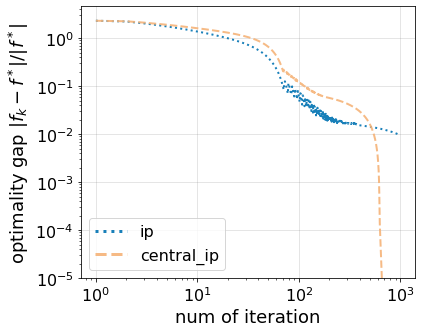

In [24]:
gradient = 'gd'
momentum = 0
# Run all algorithms and collect results
folder = f'pics/Ablation/records/'
os.makedirs(folder, exist_ok=True)

config = create_test_problem(params['problem']['convex_para'])
problem = ConvexOpt(config)
problem = problem.to_device(DEVICE)
solver = ConvexSolver(problem.prob_para)
ip_type = 'ip'
# # x_origin = solver.solve(ip_type)
# x_origin = np.zeros(2)
# hom_map = GaugeMap(problem, p_norm = 2, x_origin = x_origin)
# hom_map = hom_map.to_device(DEVICE)

st = time.time()
x_opt = solver.solve(solve_type='opt')
et = time.time()
solver_time = et - st
x_opt_tensor = torch.as_tensor(x_opt).view(1, -1).to(DEVICE)
obj_opt = problem.objective_x(x_opt_tensor).detach().cpu().numpy()


ip_list = ['ip', 'central_ip']
visualization_data = {}
alg = 'Hom-PGD'
for ip_type in ip_list:
    if ip_type == 'central_ip':
        x_origin = solver.solve(ip_type)
    else:
        x_origin = np.zeros(2)
    hom_map = GaugeMap(problem, p_norm = 2, x_origin = x_origin)
    hom_map = hom_map.to_device(DEVICE)
    file_name = f'{problem.__str__()}_{alg}_{ip_type}_{gradient}_{momentum}_record.npy'
    results = np.load(folder+file_name, allow_pickle=True).item()
    visualization_data[ip_type] = results
    plot_optimization_trajectory(problem, hom_map, results['x_traj'], 'x', alg, filename=ip_type, save_dir = 'pics/Ablation/')

for ip_type in ip_list:
    visualization_data[ip_type]['obj_gap'] = np.abs(visualization_data[ip_type]['obj_traj'] - obj_opt)/np.abs(obj_opt)
folder = f'pics/Ablation/'
path =folder + f'/{problem.__str__()}_ip'
vis(ip_list, visualization_data, path, solver=False)


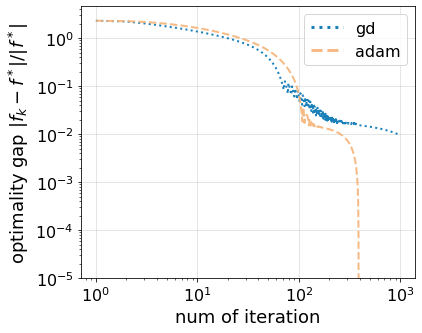

In [29]:
ip_list = ['ip', 'central_ip']
visualization_data = {}
alg = 'Hom-PGD'
gradient_list = ['gd', 'adam']
folder = f'pics/Ablation/records/'
os.makedirs(folder, exist_ok=True)
ip_type = 'ip'
for gradient in gradient_list:
    if ip_type == 'central_ip':
        x_origin = solver.solve(ip_type)
    else:
        x_origin = np.zeros(2)
    hom_map = GaugeMap(problem, p_norm = 2, x_origin = x_origin)
    hom_map = hom_map.to_device(DEVICE)
    file_name = f'{problem.__str__()}_{alg}_{ip_type}_{gradient}_{momentum}_record.npy'
    results = np.load(folder+file_name, allow_pickle=True).item()
    visualization_data[gradient] = results
    plot_optimization_trajectory(problem, hom_map, results['x_traj'], 'x', alg, filename=gradient, save_dir = 'pics/Ablation/')

for gradient in gradient_list:
    visualization_data[gradient]['obj_gap'] = np.abs(visualization_data[gradient]['obj_traj'] - obj_opt)/np.abs(obj_opt)
folder = f'pics/Ablation/'
path =folder + f'/{problem.__str__()}_gradient'
vis(gradient_list, visualization_data, path, solver=False)